# 🌾 MODULE 1: HUẤN LUYỆN MÔ HÌNH YOLO SEGMENTATION CHO HẠT LÚA
**Đề tài Nghiên cứu Khoa học**: Hệ thống thị giác máy tính và học sâu phục vụ ước lượng số lượng và đánh giá phẩm cấp hạt giống lúa.

### 🎯 Mục đích file này:
1. Kết nối Google Drive & cài đặt các thư viện cần thiết (`ultralytics`, `matplotlib`, `pyyaml`).
2. Cấu hình dataset và siêu tham số huấn luyện (Epochs, Batch size, Image size).
3. Huấn luyện mô hình phân đoạn cá thể hạt lúa (**YOLO Segmentation** - ví dụ `yolo26n-seg.pt` hoặc `yolov8n-seg.pt`).
4. Kiểm tra dự đoán thử nghiệm và tự động sao lưu toàn bộ trọng số (`best.pt`, `last.pt`) cùng biểu đồ mAP/Loss sang Google Drive.


In [1]:
# Bước 1: Kết nối Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# Bước 2: Cài đặt thư viện Ultralytics YOLO
!pip install ultralytics matplotlib pyyaml


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 7.4 MB/s eta 0:00:00


In [3]:
# Bước 3: Import các thư viện cần thiết
import os
import shutil
import matplotlib.pyplot as plt
from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [21]:
# Bước 4: CẤU HÌNH THAM SỐ HUẤN LUYỆN TỐI ƯU NHẤT CHO DỰ ÁN
BASE_PATH = "/content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/"
MODEL_NAME   = "yolov8s-seg.pt"
DATASET_NAME = "all-new-data-v1.yolov8"
EPOCHS     = 100
BATCH_SIZE = 8
IMG_SIZE   = 640
DEVICE     = 0
MODELS_DIR  = os.path.join(BASE_PATH, "MODELS")
DATASET_DIR = os.path.join(BASE_PATH, "DATASETS", DATASET_NAME)
DATA_YAML   = os.path.join(DATASET_DIR, "data.yaml")
TRAIN_EXP_NAME = f"{DATASET_NAME}_{MODEL_NAME.replace('.pt', '')}_trained"
DRIVE_SAVE_DIR = os.path.join(BASE_PATH, "RESULTS", TRAIN_EXP_NAME)


In [22]:
from cv2 import LSD_REFINE_ADV
# Bước 5: Bắt đầu Huấn luyện YOLO Segmentation (Tối ưu Augmentation)
model_path = os.path.join(MODELS_DIR, MODEL_NAME)
if not os.path.exists(model_path):
    model = YOLO(MODEL_NAME)
else:
    model = YOLO(model_path)

project_dir = "/content/rice_seed_segmentation"
results = model.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    batch=BATCH_SIZE,
    imgsz=IMG_SIZE,
    device=DEVICE,
    project=project_dir,
    name=TRAIN_EXP_NAME,
    exist_ok=True,
    patience=30,

    optimizer='SGD',         # SGD ổn định hơn AdamW-auto khi batch/dataset nhỏ, ít nguy cơ nổ gradient
    lr0=0.01,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=10,        # cần warmup dài hơn vì mỗi epoch chỉ có vài iteration

    degrees=15.0,            # giảm từ 90 -> tránh mask bị méo/suy biến khi kết hợp mosaic
    translate=0.1,
    scale=0.5,
    shear=0.0,
    perspective=0.0,
    flipud=0.5,
    fliplr=0.5,
    mosaic=0.5,               # giảm xác suất thay vì luôn bật, giảm rủi ro ảnh ghép lỗi
    close_mosaic=10,

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    cache='ram',              # dataset nhỏ, cache RAM để tránh warning "Slow image access" từ Drive
    amp=True,
    deterministic=True,
    seed=0,
)


Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=ram, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/DATASETS/all-new-data-v1.yolov8/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mod

In [23]:
# Bước 6: Thử nghiệm Dự đoán nhanh trên 1 ảnh mẫu
best_weight_local = f"/content/rice_seed_segmentation/all-new-data-v1.yolov8_yolov8s-seg_trained/weights/best.pt"

if os.path.exists(best_weight_local):
    trained_model = YOLO(best_weight_local)
    test_demo_url = "https://media.istockphoto.com/id/186786216/photo/unmilled-rice-grains.jpg"
    res = trained_model.predict(source=test_demo_url, conf=0.4, save=True)
    print("✅ Đã chạy thử nghiệm dự đoán mẫu thành công!")
else:
    print("⚠️ Không tìm thấy trọng số best.pt cục bộ.")



Found https://media.istockphoto.com/id/186786216/photo/unmilled-rice-grains.jpg locally at unmilled-rice-grains.jpg
image 1/1 /content/unmilled-rice-grains.jpg: 448x640 46 seeds, 15.8ms
Speed: 3.6ms preprocess, 15.8ms inference, 5.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/segment/predict-2
✅ Đã chạy thử nghiệm dự đoán mẫu thành công!


In [17]:
# Bước 7: Tự động sao lưu toàn bộ kết quả vào Google Drive
local_result_dir = f"/content/rice_seed_segmentation/{TRAIN_EXP_NAME}"

if os.path.exists(local_result_dir):
    os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)
    shutil.copytree(local_result_dir, DRIVE_SAVE_DIR, dirs_exist_ok=True)
    print("=" * 60)
    print(f"🎉 ĐÃ SAO LƯU THÀNH CÔNG TOÀN BỘ KẾT QUẢ VÀO GOOGLE DRIVE!")
    print(f"📂 Thư mục: {DRIVE_SAVE_DIR}")
    print(f"⭐ Trọng số tốt nhất: {os.path.join(DRIVE_SAVE_DIR, 'weights', 'best.pt')}")
    print("=" * 60)
else:
    print("❌ Không tìm thấy thư mục kết quả để sao lưu.")


🎉 ĐÃ SAO LƯU THÀNH CÔNG TOÀN BỘ KẾT QUẢ VÀO GOOGLE DRIVE!
📂 Thư mục: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/all-new-data-v1.yolov8_yolov8s-seg_trained
⭐ Trọng số tốt nhất: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/all-new-data-v1.yolov8_yolov8s-seg_trained/weights/best.pt


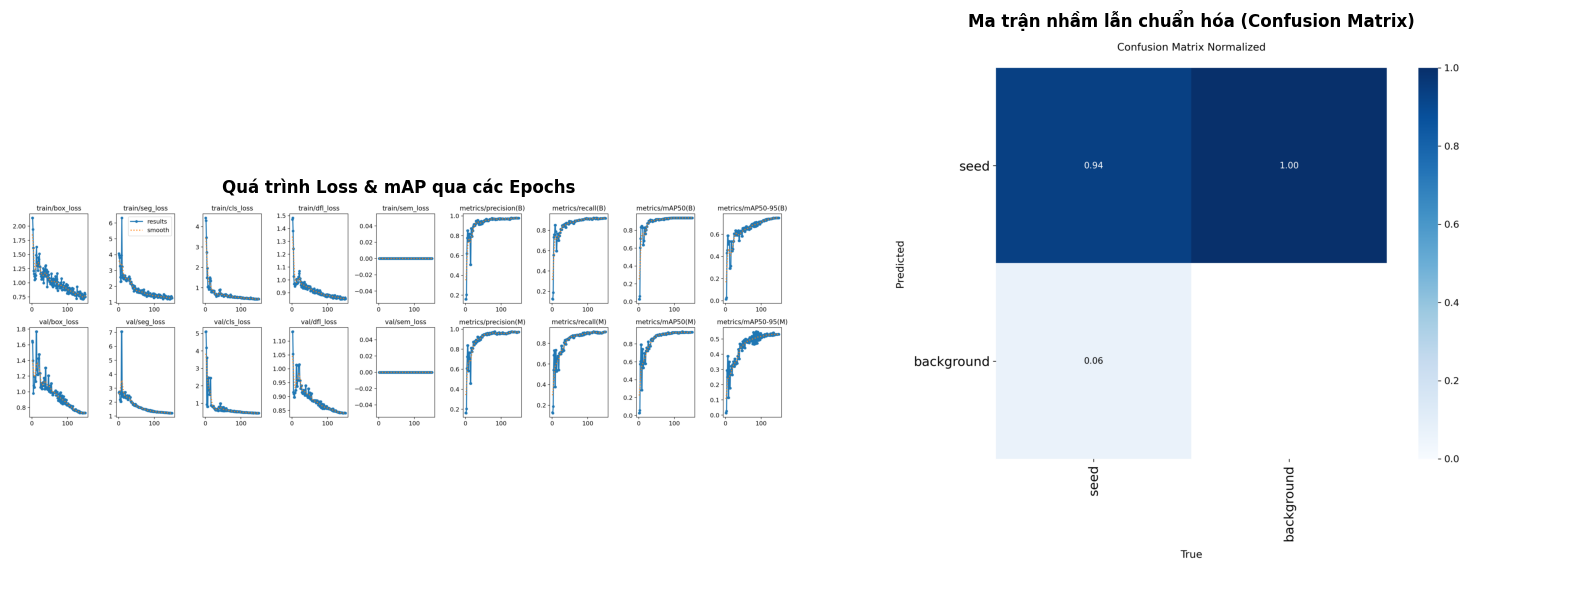

In [24]:
# Bước 8: Hiển thị Biểu đồ Kết quả và Ma trận Nhầm lẫn
results_img_path = os.path.join(DRIVE_SAVE_DIR, "results.png")
confusion_matrix_path = os.path.join(DRIVE_SAVE_DIR, "confusion_matrix_normalized.png")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if os.path.exists(results_img_path):
    img_res = plt.imread(results_img_path)
    axes[0].imshow(img_res)
    axes[0].set_title("Quá trình Loss & mAP qua các Epochs", fontsize=12, fontweight='bold')
    axes[0].axis('off')

if os.path.exists(confusion_matrix_path):
    img_cm = plt.imread(confusion_matrix_path)
    axes[1].imshow(img_cm)
    axes[1].set_title("Ma trận nhầm lẫn chuẩn hóa (Confusion Matrix)", fontsize=12, fontweight='bold')
    axes[1].axis('off')

plt.tight_layout()
plt.show()
